In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Verificar si hay GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# Cargar datos
df = pd.read_csv('../data/crude_oil_clean.csv')
df = df[df['SU100'] < 2000].copy()
df['DULCE_AGRIO'] = (df['SRC'] >= 0.5).astype(int)

features = ['API_CRUDE', 'SGRAV_CRUD', 'CRN', 'SU100',
            'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL',
            'GAS_NP_VOL', 'RESDUM_VOL']

X = df[features].values
y = df['DULCE_AGRIO'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Convertir a tensores
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"Features: {len(features)}")

Dispositivo: cpu
Train: 7084 muestras
Test:  1772 muestras
Features: 9


In [5]:
# Definir la arquitectura de la red neuronal
class RedNeuronalCrudo(nn.Module):
    def __init__(self, input_dim):
        super(RedNeuronalCrudo, self).__init__()
        self.red = nn.Sequential(
            # Capa 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Capa 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Capa 3
            nn.Linear(32, 16),
            nn.ReLU(),
            # Salida
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.red(x).squeeze()

# Instanciar modelo
modelo = RedNeuronalCrudo(input_dim=len(features)).to(device)
print(modelo)
print(f"\nParámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}")

# Optimizer y función de pérdida
# peso para clase agrio (desbalance)
peso_agrio = torch.tensor([y_train.sum() / (len(y_train) - y_train.sum())]).to(device)
criterio = nn.BCELoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Entrenamiento
EPOCHS = 80
historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Train
    modelo.train()
    train_loss = 0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        preds = modelo(X_batch)
        loss = criterio(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validación
    modelo.eval()
    with torch.no_grad():
        val_preds = modelo(X_test_t)
        val_loss = criterio(val_preds, y_test_t).item()
        val_acc = ((val_preds > 0.5).float() == y_test_t).float().mean().item()

    historial['train_loss'].append(train_loss / len(train_dl))
    historial['val_loss'].append(val_loss)
    historial['val_acc'].append(val_acc)
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss/len(train_dl):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print("\nEntrenamiento completo.")

RedNeuronalCrudo(
  (red): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Parámetros entrenables: 3,457
Época  20/80 | Train Loss: 0.3086 | Val Loss: 0.2904 | Val Acc: 0.8775
Época  40/80 | Train Loss: 0.3009 | Val Loss: 0.2834 | Val Acc: 0.8809
Época  60/80 | Train Loss: 0.2980 | Val Loss: 0.2830 | Val Acc: 0.8826
Época  80/80 | Train Loss: 0.2948 | Val Loss: 0.2831 | Val Acc: 0.8809

Entrenamiento completo.


RED NEURONAL — Resultados finales
                precision    recall  f1-score   support

Dulce (<0.5%S)       0.90      0.94      0.92      1283
Agrio (≥0.5%S)       0.82      0.73      0.77       489

      accuracy                           0.88      1772
     macro avg       0.86      0.83      0.85      1772
  weighted avg       0.88      0.88      0.88      1772

AUC-ROC: 0.9324


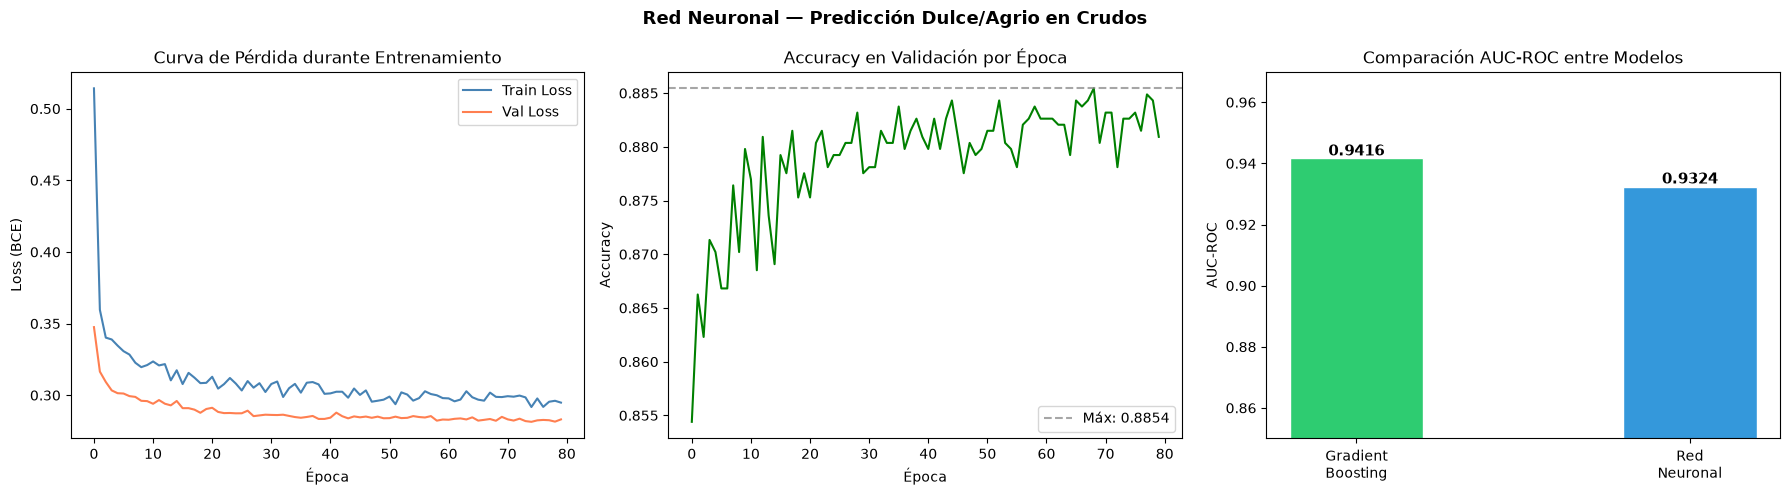


Modelo guardado en data/modelo_nn.pth


In [6]:
# Evaluación final y comparación de modelos
modelo.eval()
with torch.no_grad():
    y_proba_nn = modelo(X_test_t).cpu().numpy()
    y_pred_nn = (y_proba_nn > 0.5).astype(int)

auc_nn = roc_auc_score(y_test, y_proba_nn)

print("=" * 55)
print("RED NEURONAL — Resultados finales")
print("=" * 55)
print(classification_report(y_test, y_pred_nn,
      target_names=['Dulce (<0.5%S)', 'Agrio (≥0.5%S)']))
print(f"AUC-ROC: {auc_nn:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Red Neuronal — Predicción Dulce/Agrio en Crudos',
             fontsize=13, fontweight='bold')

# 1. Curva de pérdida
axes[0].plot(historial['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(historial['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Curva de Pérdida durante Entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].legend()

# 2. Curva de accuracy
axes[1].plot(historial['val_acc'], color='green')
axes[1].axhline(y=max(historial['val_acc']), color='gray',
                linestyle='--', alpha=0.7,
                label=f"Máx: {max(historial['val_acc']):.4f}")
axes[1].set_title('Accuracy en Validación por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. Comparación de modelos
modelos = ['Gradient\nBoosting', 'Red\nNeuronal']
aucs    = [0.9416, auc_nn]
colores = ['#2ecc71', '#3498db']
bars = axes[2].bar(modelos, aucs, color=colores, edgecolor='white', width=0.4)
axes[2].set_ylim(0.85, 0.97)
axes[2].set_title('Comparación AUC-ROC entre Modelos')
axes[2].set_ylabel('AUC-ROC')
for bar, val in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 0.001, f'{val:.4f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../data/red_neuronal_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelo
torch.save(modelo.state_dict(), '../data/modelo_nn.pth')
print("\nModelo guardado en data/modelo_nn.pth")